## Exercise 1: Ridge, Lasso und ElasticNet
**Dataset Used:** California Housing (used instead of Boston due to sklearn deprecation)

1. Train Ridge, Lasso, ElasticNet with alpha=0.1, 1, 10, 100. Plot RMSE vs alpha.
2. Visualize Lasso path (lasso_path).
3. LassoCV to find optimal alpha. Compare with unregularized.

C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\skle

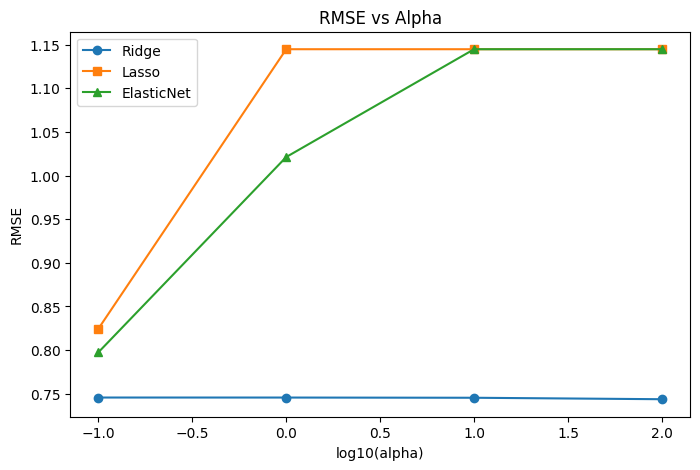

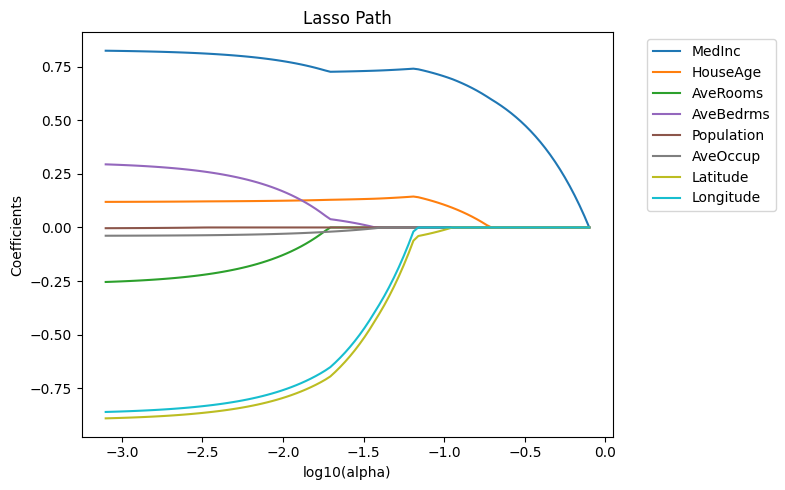

Optimal Lasso Alpha: 0.0008, RMSE: 0.7448
Unregularized Linear Regression RMSE: 0.7456


C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, lasso_path, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = [0.1, 1, 10, 100]

rmse_ridge = []
rmse_lasso = []
rmse_elastic = []

for a in alphas:
    # Ridge
    model = Ridge(alpha=a).fit(X_train, y_train)
    rmse_ridge.append(mean_squared_error(y_test, model.predict(X_test), squared=False))
    
    # Lasso
    model = Lasso(alpha=a).fit(X_train, y_train)
    rmse_lasso.append(mean_squared_error(y_test, model.predict(X_test), squared=False))
    
    # ElasticNet
    model = ElasticNet(alpha=a).fit(X_train, y_train)
    rmse_elastic.append(mean_squared_error(y_test, model.predict(X_test), squared=False))

# 1. Plot
plt.figure(figsize=(8,5))
plt.plot(np.log10(alphas), rmse_ridge, marker='o', label='Ridge')
plt.plot(np.log10(alphas), rmse_lasso, marker='s', label='Lasso')
plt.plot(np.log10(alphas), rmse_elastic, marker='^', label='ElasticNet')
plt.xlabel('log10(alpha)')
plt.ylabel('RMSE')
plt.legend()
plt.title('RMSE vs Alpha')
plt.show()

# 2. Lasso Path
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=1e-3)
plt.figure(figsize=(8,5))
colors = plt.cm.tab10(np.linspace(0, 1, len(data.feature_names)))
for i, (coef, name) in enumerate(zip(coefs_lasso, data.feature_names)):
    plt.plot(np.log10(alphas_lasso), coef, label=name, color=colors[i])
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficients')
plt.title('Lasso Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. LassoCV
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_train, y_train)
opt_alpha = lasso_cv.alpha_
pred_cv = lasso_cv.predict(X_test)
rmse_opt = mean_squared_error(y_test, pred_cv, squared=False)

# Unregularized
lin_reg = LinearRegression().fit(X_train, y_train)
pred_lin = lin_reg.predict(X_test)
rmse_lin = mean_squared_error(y_test, pred_lin, squared=False)

print(f"Optimal Lasso Alpha: {opt_alpha:.4f}, RMSE: {rmse_opt:.4f}")
print(f"Unregularized Linear Regression RMSE: {rmse_lin:.4f}")
